# Volatility Targeting: Inverse-Vol Weighted Portfolio

An **inverse-volatility weighting** strategy on QQQ/BIL/GLD using `Weigh.BasedOnHV`.
Each asset's weight is scaled so the portfolio's annualised volatility stays near a target.

When markets are calm, the strategy levers up (sum of weights > 1).
When markets are choppy, it scales down (sum < 1 = cash buffer).

This notebook demonstrates:
- `Weigh.BasedOnHV` for volatility-targeted allocation
- `Signal.Quarterly()` for quarterly rebalancing
- Parameter sensitivity analysis (different `target_hv` values)
- Weight evolution visualisation

**Offline mode**: Uses local CSV files — no network required.

In [1]:
from pathlib import Path

import pandas as pd

import tiportfolio as ti

_DATA_DIR = Path("../../tests/data")

CSV_DATA: dict[str, str] = {
    "QQQ": str(_DATA_DIR / "qqq_2018_2024_yf.csv"),
    "BIL": str(_DATA_DIR / "bil_2018_2024_yf.csv"),
    "GLD": str(_DATA_DIR / "gld_2018_2024_yf.csv"),
}

TICKERS = ["QQQ", "BIL", "GLD"]
INITIAL_RATIO = {"QQQ": 0.7, "BIL": 0.2, "GLD": 0.1}
START = "2019-01-01"
END = "2024-12-31"

## 1. Load Data

In [2]:
data = ti.fetch_data(TICKERS, start=START, end=END, csv=CSV_DATA)

for ticker, df in data.items():
    print(f"{ticker}: {df.shape[0]} rows, {df.index[0].date()} \u2192 {df.index[-1].date()}")

QQQ: 1760 rows, 2018-01-02 → 2024-12-30
BIL: 1760 rows, 2018-01-02 → 2024-12-30
GLD: 1760 rows, 2018-01-02 → 2024-12-30


## 2. Volatility-Targeting Strategy (target = 15%)

`Weigh.BasedOnHV` scales an initial ratio up or down so the portfolio's annualised
volatility stays near `target_hv`. It uses a diagonal covariance approximation over
the lookback window.

- When realised vol < target \u2192 weights scale **up** (leverage)
- When realised vol > target \u2192 weights scale **down** (cash buffer)

In [3]:
vol_target = ti.Portfolio(
    "vol_target_15pct",
    [
        ti.Signal.Quarterly(),
        ti.Select.All(),
        ti.Weigh.BasedOnHV(
            initial_ratio=INITIAL_RATIO,
            target_hv=0.15,
            lookback=pd.DateOffset(months=1),
        ),
        ti.Action.Rebalance(),
    ],
    TICKERS,
)

result = ti.run(ti.Backtest(vol_target, data))

## 3. Results

In [4]:
result.summary()

,value
sharpe,0.498
calmar,0.446
sortino,0.604
max_drawdown,-0.295
cagr,0.131
risk_free_rate,0.040
total_return,1.369
kelly,2.319
final_value,23693.268
total_fee,4.319


In [14]:
result.plot_interactive()

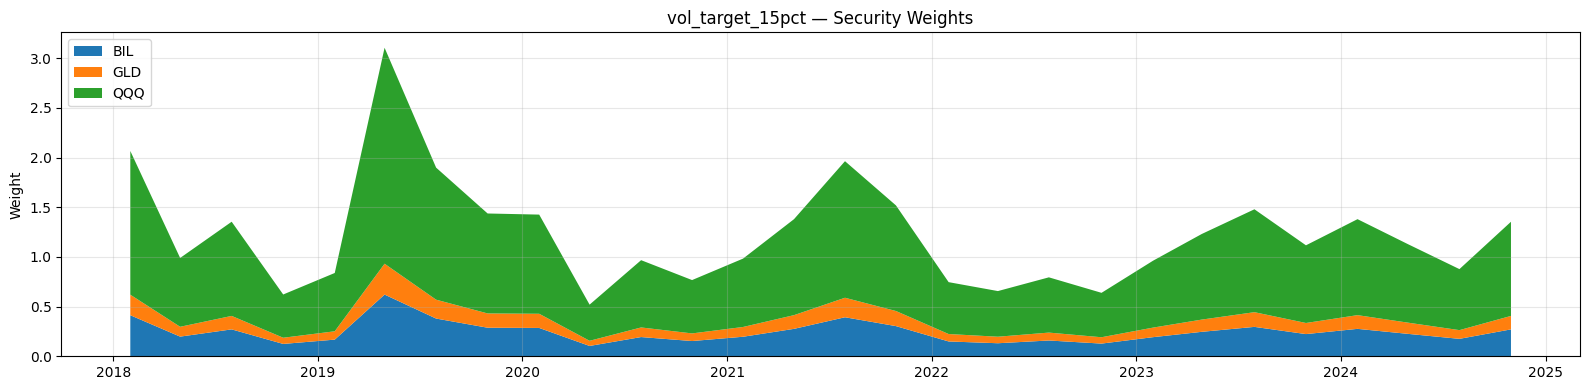

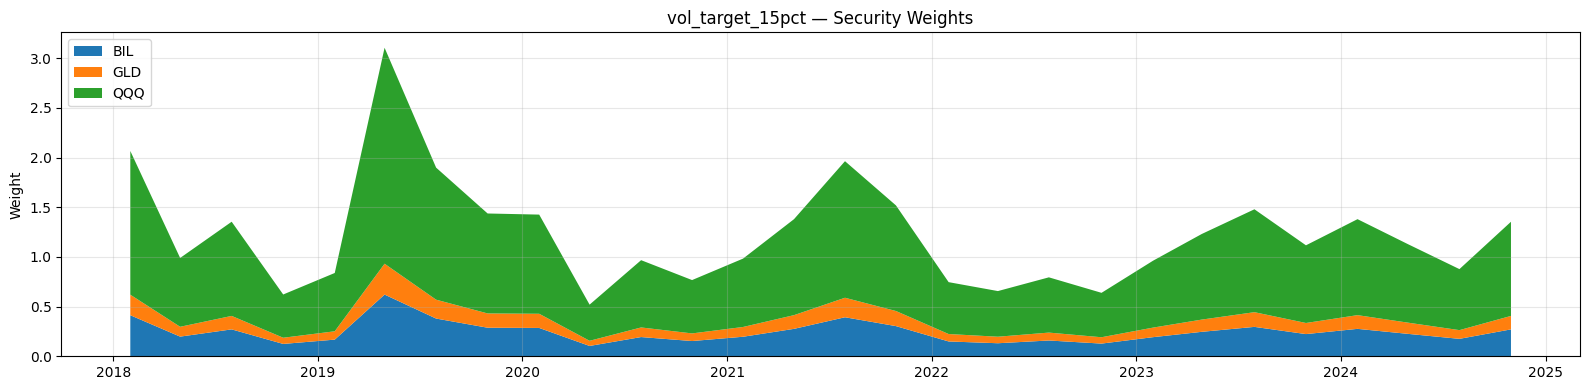

In [6]:
result[0].plot_security_weights()

In [7]:
result[0].trades.sample(5)

,date,portfolio,ticker,qty_before,qty_after,delta,price,fee,equity_before,equity_after
51,2022-04-29 04:00:00+00:00,vol_target_15pct,QQQ,23.966021,22.761541,-1.204480,305.828674,0.004216,15146.892769,15146.863436
52,2022-04-29 04:00:00+00:00,vol_target_15pct,BIL,31.102860,25.515860,-5.587000,77.947395,0.019555,15146.892769,15146.863436
53,2022-04-29 04:00:00+00:00,vol_target_15pct,GLD,7.210627,5.621205,-1.589422,176.910004,0.005563,15146.892769,15146.863436
54,2022-07-29 04:00:00+00:00,vol_target_15pct,QQQ,22.761541,27.297533,4.535992,308.578369,0.015876,15140.359074,15140.318605
55,2022-07-29 04:00:00+00:00,vol_target_15pct,BIL,25.515860,30.830670,5.314810,78.061676,0.018602,15140.359074,15140.318605
18,2019-07-31 04:00:00+00:00,vol_target_15pct,QQQ,120.223377,74.919137,-45.304239,183.629761,0.158565,10347.493341,10342.817170
19,2019-07-31 04:00:00+00:00,vol_target_15pct,BIL,81.373147,50.946356,-30.426791,77.153328,0.106494,10347.493341,10342.817170
20,2019-07-31 04:00:00+00:00,vol_target_15pct,GLD,25.752073,14.753700,-10.998373,133.210007,0.038494,10347.493341,10342.817170
45,2021-10-29 04:00:00+00:00,vol_target_15pct,QQQ,63.324091,49.261067,-14.063023,376.016815,0.049221,17420.597724,17417.233311
46,2021-10-29 04:00:00+00:00,vol_target_15pct,BIL,82.301888,67.889655,-14.412233,77.954185,0.050443,17420.597724,17417.233311


## 4. Baseline Comparisons

Compare against:
1. **Fixed 70/20/10** \u2014 same initial allocation but no vol adjustment, monthly rebalance
2. **QQQ Only** \u2014 100% QQQ buy-and-hold

In [8]:
fixed_ratio = ti.Portfolio(
    "fixed_70_20_10",
    [ti.Signal.Monthly(), ti.Select.All(), ti.Weigh.Ratio(weights=INITIAL_RATIO), ti.Action.Rebalance()],
    TICKERS,
)

qqq_only = ti.Portfolio(
    "qqq_only",
    [ti.Signal.Once(), ti.Select.All(), ti.Weigh.Equally(), ti.Action.Rebalance()],
    ["QQQ"],
)

comparison = ti.run(
    ti.Backtest(vol_target, data),
    ti.Backtest(fixed_ratio, data),
    ti.Backtest(qqq_only, data),
)

In [9]:
comparison.summary()

,vol_target_15pct,fixed_70_20_10,qqq_only
sharpe,0.498,0.642,0.684
calmar,0.446,0.546,0.547
sortino,0.604,0.833,0.889
max_drawdown,-0.295,-0.264,-0.351
cagr,0.131,0.144,0.192
risk_free_rate,0.040,0.040,0.040
total_return,1.369,1.559,2.411
kelly,2.319,3.784,2.835
final_value,23693.268,25588.316,34106.625
total_fee,4.319,0.939,0.233


In [10]:
comparison.plot_interactive()

## 5. Target Volatility Sensitivity

Re-run with a lower target (10%) to see how a more conservative vol target affects returns and drawdowns.

In [11]:
vol_target_10 = ti.Portfolio(
    "vol_target_10pct",
    [
        ti.Signal.Quarterly(),
        ti.Select.All(),
        ti.Weigh.BasedOnHV(
            initial_ratio=INITIAL_RATIO,
            target_hv=0.10,
            lookback=pd.DateOffset(months=1),
        ),
        ti.Action.Rebalance(),
    ],
    TICKERS,
)

sensitivity = ti.run(
    ti.Backtest(vol_target, data),
    ti.Backtest(vol_target_10, data),
)

In [12]:
sensitivity.summary()

,vol_target_15pct,vol_target_10pct
sharpe,0.498,0.438
calmar,0.446,0.479
sortino,0.604,0.534
max_drawdown,-0.295,-0.200
cagr,0.131,0.096
risk_free_rate,0.040,0.040
total_return,1.369,0.896
kelly,2.319,3.125
final_value,23693.268,18956.428
total_fee,4.319,2.678


In [13]:
sensitivity.plot_interactive()